# 캐글필사  - Decision Tree and Random Forest Classifier Models

In [77]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
prathamtripathi_drug_classification_path = kagglehub.dataset_download('prathamtripathi/drug-classification')
prathamtripathi_classification_accuracy_97_5_path = kagglehub.notebook_output_download('prathamtripathi/classification-accuracy-97-5')

print('Data source import complete.')


Data source import complete.


In [78]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
# /kagge/input에 아무것도 저장되어있지 않다면 아무것도 출력안됨.

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/drug-classification/drug200.csv


In [79]:
import warnings
warnings.filterwarnings("ignore")

In [80]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Data Review

In [81]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]


# Set the path to the file you'd like to load
file_path = "drug200.csv"

# Load the latest version
data = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "prathamtripathi/drug-classification",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", data.head())

First 5 records:    Age Sex      BP Cholesterol  Na_to_K   Drug
0   23   F    HIGH        HIGH   25.355  DrugY
1   47   M     LOW        HIGH   13.093  drugC
2   47   M     LOW        HIGH   10.114  drugC
3   28   F  NORMAL        HIGH    7.798  drugX
4   61   F     LOW        HIGH   18.043  DrugY


In [82]:
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [83]:
data.info()
# 결측치 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [84]:
# data statistics
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [85]:
# col간 상관계수 확인하기
data.corr(numeric_only = True)

,Age,Na_to_K
Age,1.000000,-0.063119
Na_to_K,-0.063119,1.000000


<Axes: >

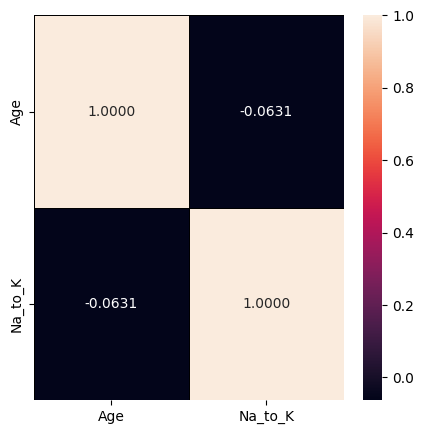

In [86]:
# correlation Heatmap으로 시각화
f, ax = plt.subplots(figsize = (5,5))
sns.heatmap(data.corr(numeric_only = True),annot = True,
           linewidth=0.5, linecolor = "black",
           fmt = ".4f", ax=ax)

hue = "Drug" > drug에 따라 색 구별

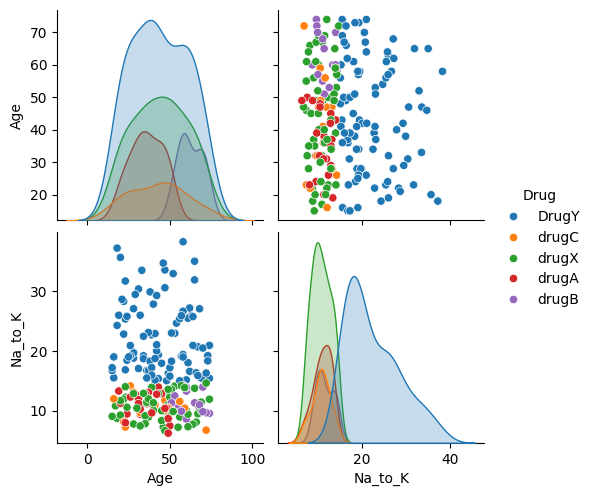

In [87]:
sns.pairplot(data,hue="Drug")

In [88]:
# Dataset columns 이름들
data.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

⬇️ column별 데이터 확인

In [89]:
data['Age'].value_counts(dropna=False)

,count
Age,
47,8
23,7
28,7
49,7
32,6
39,6
50,5
60,5
22,5


In [90]:
data['Sex'].value_counts()

,count
Sex,
M,104
F,96


In [91]:
data['BP'].value_counts()

,count
BP,
HIGH,77
LOW,64
NORMAL,59


In [92]:
data['Cholesterol'].value_counts()

,count
Cholesterol,
HIGH,103
NORMAL,97


In [93]:
data['Drug'].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


# Data visualization

Age 시각화 - 도수분포표

In [146]:
dataAge = data["Age"].value_counts(dropna = False)
npar_dataAge = np.array(dataAge)
x = list(npar_dataAge) # 도수
y = data.Age.value_counts().index # 나이
print(x,"\n",y)
DataAge = {'Age':y,'Number':x}
DataAge = pd.DataFrame(DataAge)

fig = px.bar(DataAge,x='Age',y='Number')
fig.show()

[np.int64(8), np.int64(7), np.int64(7), np.int64(7), np.int64(6), np.int64(6), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)] 
 Index([47, 23, 28, 49, 32, 39, 50, 60, 22, 37, 58, 43, 41, 57, 65, 61, 74, 45,
       56, 24, 26, 67, 68, 31, 34, 51, 42, 20, 72, 36, 69, 18, 16, 35, 59, 64,
       53, 38, 70, 15, 40, 55, 52, 48, 29, 73, 46, 66, 62, 19, 63, 33, 17, 54,
       30, 21, 25],

Sex 시각화 - pie chart (정성)

In [95]:
colors = ['gold','mediumturquoise']
fig = go.Figure(data = [go.Pie(labels = ['M','F'],
                              values = [104, 96])])
fig.update_traces(hoverinfo = 'label + percent',
                 textinfo = 'value',
                 textfont_size = 20,
                 marker = dict(colors = colors,
                line = dict(color='#000000',width=2)))
fig.show() # 성별을 pie chart 로 나타냄

BP 시각화 - bar plot

In [96]:
fig = px.bar (x = ['High','Low','Normal'],
             y= [77,64,59]) # y는 사람수
fig.show()

Cholesterol 시각화 - bar plot

In [97]:
fig = px.histogram(x=['High','Normal'],
                  y = [103,97])
fig.show()

Drug 시각화 - pie chart(정성)

In [98]:
fig = go.Figure(data = [go.Pie(labels=["DrugY","DrugX","DrugA","DrugC","DrugB"], values=[91,54,23,16,16])])

fig.update_traces(hoverinfo = 'label + percent', textinfo = 'value', textfont_size = 20,
                 marker = dict(colors = px.colors.sequential.RdBu, line = dict( color = '#000000', width = 2)))

fig.show()

In [99]:
# Drug의 수 dataset에서 시각화

fig = go.Figure(data = [go.Pie(labels = ["DrugY","DrugX","DrugA","DrugB","DrugC"],
                              values = [91,54,23,16,16])])
fig.update_traces(hoverinfo="label+percent", # 오타나면 안됨 단순히 x,y이름
                 textinfo = 'value',
                 textfont_size = 20,
                 marker = dict(colors = px.colors.sequential.RdBu,
                line = dict(color = "#000000", width = 2)))
fig.show()

#fig.update_traces
#hoverinfo : 마우스를 오렸을 때 표시할 정보 설정 ( label,value, percent)
#textinfo : 차트에 표시할 텍스트 정보 (label, value, percent) , +로 둘다 출력 가능


Age - Na_to_K 상관관계 시각화

In [100]:
fig = px.scatter(data, x = 'Na_to_K',y = 'Age',
                 color='Drug',size='Age',hover_data=['Na_to_K'])
fig.show()

# Classification Models

## Data Preparing

data 초기화

In [101]:
dataclass = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "prathamtripathi/drug-classification",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

In [102]:
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [103]:
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


one-hot encoding / Male : 0, Female : 1

In [104]:
dataclass.Sex = [1 if i=='F' else 0 for i in dataclass.Sex]

In [105]:
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,HIGH,HIGH,25.355,DrugY
1,47,0,LOW,HIGH,13.093,drugC
2,47,0,LOW,HIGH,10.114,drugC
3,28,1,NORMAL,HIGH,7.798,drugX
4,61,1,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,LOW,HIGH,11.567,drugC
196,16,0,LOW,HIGH,12.006,drugC
197,52,0,NORMAL,HIGH,9.894,drugX
198,23,0,NORMAL,NORMAL,14.020,drugX


one - hot encoding / low = 2, normal = 1, high = 0

In [106]:
for i in range(0,len(dataclass.BP)):
    if dataclass.BP[i] == "LOW":
        dataclass.BP[i] = 2
    elif dataclass.BP[i] == "NORMAL":
        dataclass.BP[i] = 1
    else:
        dataclass.BP[i] = 0

In [107]:
dataclass # 확인

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,HIGH,25.355,DrugY
1,47,0,2,HIGH,13.093,drugC
2,47,0,2,HIGH,10.114,drugC
3,28,1,1,HIGH,7.798,drugX
4,61,1,2,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,2,HIGH,11.567,drugC
196,16,0,2,HIGH,12.006,drugC
197,52,0,1,HIGH,9.894,drugX
198,23,0,1,NORMAL,14.020,drugX


인코딩 / Cholesterol : High > 1 , Normal > 0

In [108]:
dataclass['Cholesterol'] = [1 if i == 'HIGH' else 0 for i in dataclass['Cholesterol']]

In [109]:
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,1,25.355,DrugY
1,47,0,2,1,13.093,drugC
2,47,0,2,1,10.114,drugC
3,28,1,1,1,7.798,drugX
4,61,1,2,1,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,2,1,11.567,drugC
196,16,0,2,1,12.006,drugC
197,52,0,1,1,9.894,drugX
198,23,0,1,0,14.020,drugX


label encoding / Drug : Y > 4, X > 3, A > 2, C > 1, B > 0

In [110]:
for i in range(0,len(dataclass)):
    if dataclass.Drug[i] == "DrugY":
        dataclass.Drug[i] = 4
    elif dataclass.Drug[i] == "drugX":
        dataclass.Drug[i] = 3
    elif dataclass.Drug[i] == "drugA":
        dataclass.Drug[i] = 2
    elif dataclass.Drug[i] == "drugC":
        dataclass.Drug[i] = 1
    else:
        dataclass.Drug[i] = 0


In [111]:
dataclass # 최종

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,1,25.355,4
1,47,0,2,1,13.093,1
2,47,0,2,1,10.114,1
3,28,1,1,1,7.798,3
4,61,1,2,1,18.043,4
...,...,...,...,...,...,...
195,56,1,2,1,11.567,1
196,16,0,2,1,12.006,1
197,52,0,1,1,9.894,3
198,23,0,1,0,14.020,3


In [112]:
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.5+ KB


In [113]:
# dataclass type int타입으로 변환
data_types_dict={'BP':int,"Drug":int}
dataclass=dataclass.astype(data_types_dict)
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


In [114]:
x_data = dataclass.drop(["Drug"],axis = 1)

y_data = dataclass.Drug.values

In [115]:
x_data

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,1,0,1,25.355
1,47,0,2,1,13.093
2,47,0,2,1,10.114
3,28,1,1,1,7.798
4,61,1,2,1,18.043
...,...,...,...,...,...
195,56,1,2,1,11.567
196,16,0,2,1,12.006
197,52,0,1,1,9.894
198,23,0,1,0,14.020


In [116]:
y_data

array([4, 1, 1, 3, 4, 3, 4, 1, 4, 4, 1, 4, 4, 4, 3, 4, 3, 2, 1, 4, 4, 4,
       4, 4, 4, 4, 4, 3, 4, 4, 3, 0, 3, 4, 3, 3, 2, 3, 3, 3, 4, 0, 4, 3,
       3, 3, 2, 1, 4, 4, 4, 3, 4, 4, 0, 1, 0, 4, 3, 4, 4, 2, 4, 3, 0, 4,
       2, 3, 4, 4, 0, 4, 3, 4, 4, 4, 2, 4, 2, 3, 0, 3, 1, 2, 1, 0, 3, 4,
       4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 2, 2, 1, 3, 4, 3, 3, 4, 0, 4,
       2, 3, 3, 3, 3, 4, 3, 3, 2, 4, 4, 4, 4, 4, 0, 4, 4, 3, 4, 3, 4, 4,
       3, 4, 4, 3, 0, 2, 0, 3, 2, 4, 0, 4, 2, 3, 3, 2, 3, 1, 2, 0, 3, 3,
       4, 1, 2, 4, 1, 3, 3, 0, 3, 4, 4, 4, 4, 3, 4, 2, 3, 3, 4, 4, 2, 4,
       2, 4, 4, 4, 4, 3, 3, 4, 4, 4, 0, 2, 4, 4, 4, 2, 4, 1, 4, 1, 1, 3,
       3, 3])

In [117]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x_data,y_data,
                                                test_size=0.3,random_state =1)

## Decision Tree Classifier

In [118]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

In [119]:
dtc = DecisionTreeClassifier()

dtc.fit(X_train,y_train)

predict = dtc.predict(X_test)

print('The accuracy of the DecisionTree is ',metrics.accuracy_score(predict,y_test))

The accuracy of the DecisionTree is  0.9666666666666667


### Decision Tree Classifier with 'gini'

In [120]:
DTC_gini = DecisionTreeClassifier(criterion = 'gini',max_depth=3,random_state=0)

DTC_gini.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [121]:
y_pred_gini = DTC_gini.predict(X_test)

In [122]:
from sklearn.metrics import accuracy_score
print('Model Accuracy Score with criterion gini index : {0:0.4f}'.format(accuracy_score(y_test,y_pred_gini)))

Model Accuracy Score with criterion gini index : 0.9000


In [123]:
y_pred_train_gini = DTC_gini.predict(X_train)
y_pred_train_gini

array([3, 3, 2, 4, 2, 3, 3, 3, 4, 2, 0, 3, 4, 3, 4, 3, 4, 3, 4, 4, 4, 4,
       3, 4, 2, 4, 3, 3, 2, 3, 4, 2, 0, 0, 3, 3, 3, 3, 3, 4, 4, 4, 4, 3,
       3, 0, 0, 2, 4, 3, 4, 3, 4, 4, 3, 3, 4, 4, 2, 4, 4, 4, 2, 3, 4, 4,
       4, 3, 4, 3, 3, 2, 3, 2, 4, 4, 4, 4, 3, 4, 0, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 3, 4, 3, 2, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4,
       4, 2, 3, 3, 3, 4, 3, 4, 4, 4, 0, 4, 2, 3, 3, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 3, 4, 2, 3, 2, 3])

In [124]:
print('Training-set accuracy score:{0:.4f}'.format(accuracy_score(y_train,y_pred_train_gini)))

Training-set accuracy score:0.9143


In [125]:
print('Training set score: {:.4f}'.format(DTC_gini.score(X_train,y_train)))
print('Test set score: {:.4f}'.format(DTC_gini.score(X_test,y_test)))

Training set score: 0.9143
Test set score: 0.9000


### Decision Tree Classifier with "entropy"

In [126]:
DTC_en = DecisionTreeClassifier(criterion = 'entropy',max_depth = 3, random_state = 0)

DTC_en.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [127]:
y_pred_en = DTC_en.predict(X_test)

In [128]:
print('Model accuracy score with criterion entropy:{:.4f}'.format(accuracy_score(y_test,y_pred_en)))

Model accuracy score with criterion entropy:0.9000


In [129]:
y_pred_train_en = DTC_en.predict(X_train)

y_pred_train_en

array([3, 3, 2, 4, 2, 3, 3, 3, 4, 2, 0, 3, 4, 3, 4, 3, 4, 3, 4, 4, 4, 4,
       3, 4, 2, 4, 3, 3, 2, 3, 4, 2, 0, 0, 3, 3, 3, 3, 3, 4, 4, 4, 4, 3,
       3, 0, 0, 2, 4, 3, 4, 3, 4, 4, 3, 3, 4, 4, 2, 4, 4, 4, 2, 3, 4, 4,
       4, 3, 4, 3, 3, 2, 3, 2, 4, 4, 4, 4, 3, 4, 0, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 3, 4, 3, 2, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4,
       4, 2, 3, 3, 3, 4, 3, 4, 4, 4, 0, 4, 2, 3, 3, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 3, 4, 2, 3, 2, 3])

In [130]:
print("Training-set accuracy score:{:.4f}".format(accuracy_score(y_train,y_pred_train_en)))

Training-set accuracy score:0.9143


In [131]:
print('Training set score:{:.4f}'.format(DTC_en.score(X_train,y_train)))
print('Test set score:{:.4f}'.format(DTC_en.score(X_test,y_test)))

Training set score:0.9143
Test set score:0.9000


## Random Forest Classifier

In [132]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=0)
rfc.fit(X_train,y_train)

pred_rfc0 = rfc.predict(X_test)

print('The accuracy of the Random Forest is ',accuracy_score(pred_rfc0,y_test))

The accuracy of the Random Forest is  0.95


In [133]:
rfc_100 = RandomForestClassifier(n_estimators=100,random_state=0)
rfc_100.fit(X_train,y_train)
pred_rfc100 = rfc_100.predict(X_test)
print('The accuracy of the Random Forest is',accuracy_score(pred_rfc100,y_test))

The accuracy of the Random Forest is 0.95


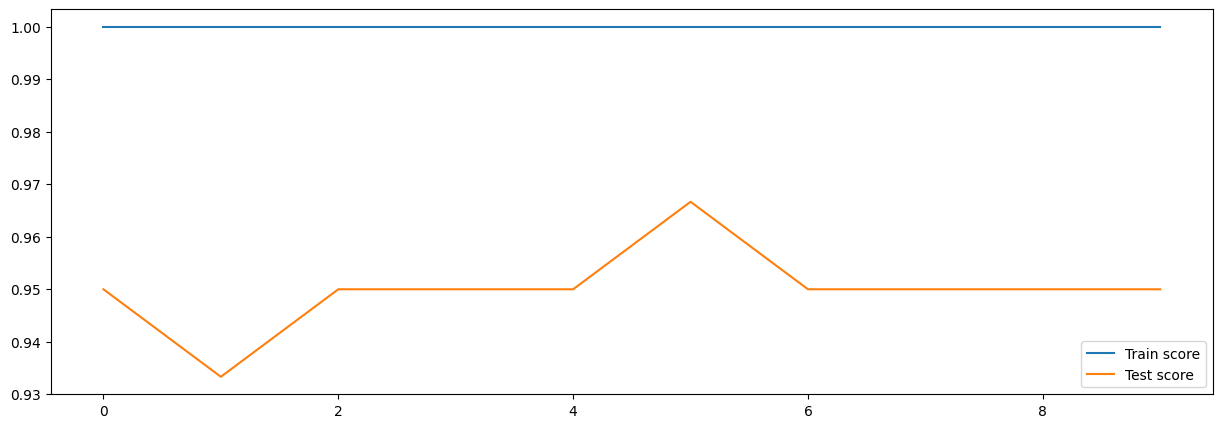

In [134]:
# Finding best random_state value
test_score_list = []
train_score_list = []

for i in range(0,10):
  rfc2 = RandomForestClassifier(random_state=i)
  rfc2.fit(X_train,y_train)
  test_score_list.append(rfc2.score(X_test,y_test))
  train_score_list.append(rfc2.score(X_train,y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0,10),y=train_score_list, markers='*',label = "Train score")
p = sns.lineplot(x=range(0,10),y=test_score_list, markers='o',label = "Test score")

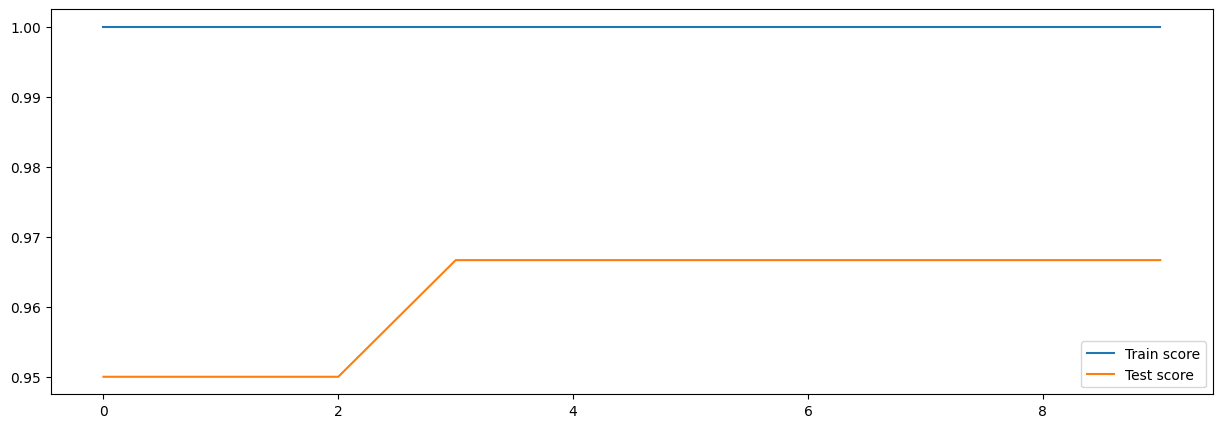

In [135]:
# finding best n_estimators parameter
test_score_list = []
train_score_list = []

n_estimators_list = [10,20,30,40,50,60,70,80,90,100]
for i in range(0,len(n_estimators_list)):
  rfc3 = RandomForestClassifier(n_estimators=n_estimators_list[i],random_state=5)
  rfc3.fit(X_train,y_train)
  test_score_list.append(rfc3.score(X_test,y_test))
  train_score_list.append(rfc3.score(X_train,y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0,len(n_estimators_list)),y=train_score_list, markers='*',label = "Train score")
p = sns.lineplot(x=range(0,len(n_estimators_list)),y=test_score_list, markers='o',label = "Test score")

### Random Forest Classifier With the Best Parameters

In [136]:
final_rfc = RandomForestClassifier(n_estimators=100, random_state=5)

final_rfc.fit(X_train,y_train)

pred_fin = final_rfc.predict(X_test)

print('Model Accuracy score with best parameters :',accuracy_score(y_test,pred_fin))

Model Accuracy score with best parameters : 0.9666666666666667


In [137]:
y_pred_fi_train = final_rfc.predict(X_train)

y_pred_fi_train

array([3, 3, 2, 4, 2, 3, 3, 3, 4, 2, 0, 1, 4, 1, 4, 3, 4, 3, 4, 4, 4, 4,
       3, 4, 2, 4, 1, 3, 2, 3, 4, 2, 0, 0, 3, 3, 1, 3, 3, 4, 4, 4, 4, 3,
       1, 0, 0, 2, 4, 3, 4, 1, 4, 4, 1, 3, 4, 4, 2, 4, 4, 4, 2, 3, 4, 4,
       4, 3, 4, 1, 3, 2, 3, 2, 4, 4, 4, 4, 3, 4, 0, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 3, 4, 3, 2, 4, 1, 4, 4, 3, 4, 4, 4, 4, 4, 4, 1, 4,
       4, 2, 3, 1, 1, 4, 3, 4, 4, 4, 0, 4, 2, 3, 3, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 3, 4, 2, 3, 2, 3])

In [138]:
print('training-set accuracy score: {:.4f}'.format(accuracy_score(y_train, y_pred_fi_train)))

training-set accuracy score: 1.0000


In [139]:
print('Training set score:{:.4f}'.format(final_rfc.score(X_train,y_train)))
print('Test set score:{:.4f}'.format(final_rfc.score(X_test,y_test)))

Training set score:1.0000
Test set score:0.9667


## Evaluation Classification Models with confusion matrix

### Confusion Matrix for DecisionTreeCalssifier Without Parameters

In [140]:
from sklearn.metrics import confusion_matrix

cm_des = DecisionTreeClassifier()
cm_des.fit(X_train,y_train)

y_pred_cm = cm_des.predict(X_test)
y_true = y_test
cm_des1 = confusion_matrix(y_true,y_pred_cm)
cm_des1

array([[ 4,  0,  2,  0,  0],
       [ 0,  4,  0,  0,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]])

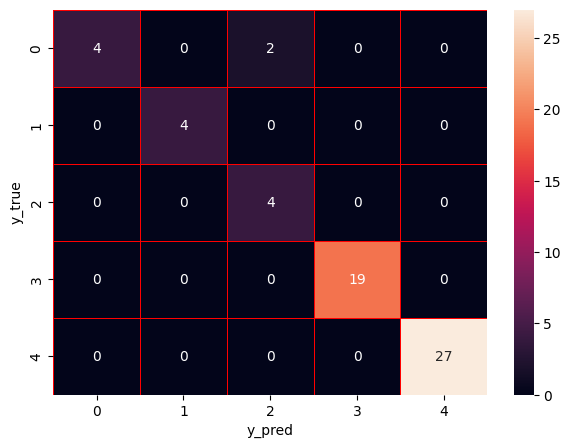

In [141]:
f,ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des1,annot=True,
            linewidths=0.5, linecolor='red',fmt='.0f',ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Confusion Matrix for DecisionTreeClassifier with "gini"

In [142]:
cm_des_gini = DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)

cm_des_gini.fit(X_train,y_train)

y_pred_cm = cm_des_gini.predict(X_test)
y_true = y_test

cm_des2 = confusion_matrix(y_true,y_pred_cm)
cm_des2

array([[ 4,  0,  2,  0,  0],
       [ 0,  0,  0,  4,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]])

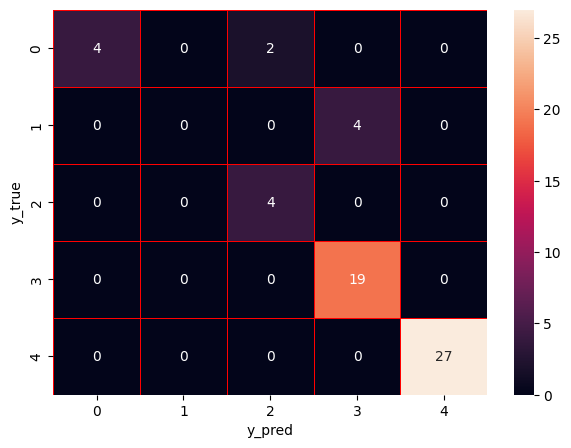

In [143]:
f,ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des2,annot=True,
            linewidths=0.5, linecolor='red',fmt='.0f',ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

### Confusion Matrix for RandomForestClassifier with the Best Parameters

In [144]:
cm_last_rfc = RandomForestClassifier(n_estimators=100,random_state=5)
cm_last_rfc.fit(X_train,y_train)

y_pred_cm = cm_last_rfc.predict(X_test)
y_true = y_test

cm_rfc = confusion_matrix(y_true,y_pred_cm)
cm_rfc

array([[ 4,  0,  2,  0,  0],
       [ 0,  4,  0,  0,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]])

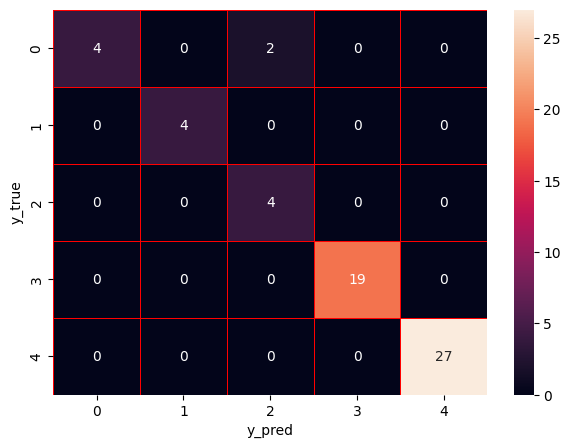

In [145]:
f,ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_rfc,annot=True,linewidths=0.5,linecolor='red',fmt='.0f',ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()